In [1]:
import os
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from sgimc.utils import save, load

import pandas as pd

In [2]:
def get_final_results(results, param="train_size", hyp_param="C_group"):
    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # averaging the cross-validation results
    results_avg = []

    for ids in id_groups:
        val_res = [id_result[_id] for _id in ids]
        avg_res = np.mean(val_res, axis=0)
        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2, 3]]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    return results_final.T

In [3]:
def get_test_results(results, param="train_size", hyp_param="C_group"):
    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            # result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # averaging the cross-validation results
    results_avg = []

    for ids in id_groups:
        val_res = [id_result[_id] for _id in ids]
        avg_res = np.median(val_res, axis=0)
        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2]]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 2]])

    results_final = np.array(results_final)

    return results_final.T

## Case 1: clear

In [ ]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis/cv_data")

PATH_OUTPUT = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis/tuberculosis/separate"
)

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [11]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/separate/results_bissgl.gz']

In [17]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [18]:
results

[[{'train_size': 0.001,
   'xi': 1,
   'eta': 2e-07,
   'tilde_lambda0': 10,
   'tilde_lambda1': 3,
   'lambda0': 10,
   'lambda1': 3,
   'K': 13,
   'test_score': 0.5403610314168595,
   'test_d1': 9684,
   'test_d2': 32},
  {'train_size': 0.001,
   'xi': 1.3,
   'eta': 2e-07,
   'tilde_lambda0': 10,
   'tilde_lambda1': 3,
   'lambda0': 10,
   'lambda1': 3,
   'K': 13,
   'test_score': 0.5141689566559365,
   'test_d1': 9684,
   'test_d2': 33},
  {'train_size': 0.001,
   'xi': 1.5,
   'eta': 2e-07,
   'tilde_lambda0': 10,
   'tilde_lambda1': 3,
   'lambda0': 10,
   'lambda1': 3,
   'K': 13,
   'test_score': 0.47747691942780646,
   'test_d1': 9684,
   'test_d2': 33},
  {'train_size': 0.021,
   'xi': 1,
   'eta': 2e-07,
   'tilde_lambda0': 10,
   'tilde_lambda1': 3,
   'lambda0': 10,
   'lambda1': 3,
   'K': 13,
   'test_score': 0.8385728204015794,
   'test_d1': 9684,
   'test_d2': 33},
  {'train_size': 0.021,
   'xi': 1.3,
   'eta': 2e-07,
   'tilde_lambda0': 10,
   'tilde_lambda1': 3,
 

In [19]:
results_final = []
for result in results:
    results_final.append(
        get_test_results(result, param="train_size", hyp_param="lambda0")
    )
results_final = np.array(results_final)
results_bissgl = np.mean(results_final, axis=0)

In [20]:
results_bissgl = np.sort(results_bissgl)

In [21]:
results_bissgl

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.51416896, 0.85565441, 0.89370862, 0.91707529, 0.92938809,
        0.93793807, 0.94486663, 0.95156858, 0.95453103, 0.95661516]])

### IMC

In [22]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/separate/results_imc.gz']

In [23]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [24]:
results

[[{'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 0,
   'val_score': 0.875,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 1,
   'val_score': 0.8051948051948052,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 2,
   'val_score': 0.986111111111111,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 3,
   'val_score': 0.7272727272727273,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 4,
   'val_score': 0.8214285714285714,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 10,
   'cv': 0,
   'val_score': 0.8,
   'test_score': 0.8149562338301892},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 10,
   'cv': 1,
   'val_score': 0.7638888888888888,
   'test_score': 0.8149562338301892},
  {'train_size': 0.001,
   'lam

In [25]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="lamb")
    )
results_final = np.array(results_final)
results_imc = np.mean(results_final, axis=0)

In [26]:
results_imc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.81513506, 0.91116569, 0.92186022, 0.93661297, 0.94045576,
        0.94385873, 0.94370521, 0.94642395, 0.9488162 , 0.94966757]])

### SGIMC

In [27]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/separate/results_sgimc.gz']

In [28]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [29]:
results

[[{'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 0,
   'rank': 5,
   'val_score': 0.875,
   'val_d1': 496,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 1,
   'rank': 5,
   'val_score': 0.8051948051948051,
   'val_d1': 501,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 2,
   'rank': 5,
   'val_score': 0.986111111111111,
   'val_d1': 521,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 3,
   'rank': 5,
   'val_score': 0.7792207792207793,
   'val_d1': 423,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 4,
   'rank': 5,
   'val_score': 0.8392857142857143,
   'val_d1': 499,
   'val_d2': 22,

In [30]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="rank")
    )
results_final = np.array(results_final)
results_sgimc = np.mean(results_final, axis=0)

In [31]:
results_sgimc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.81564811, 0.91996774, 0.93506986, 0.94328655, 0.9489963 ,
        0.95320304, 0.95531274, 0.95603846, 0.95744808, 0.95892454]])

### DRIMC

In [37]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/separate/results_drimc.gz']

In [38]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [39]:
results

[[{'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 1,
   'iterpara': 0.09,
   'numLat': 1000,
   'test_score': 0.4937336998852749,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 2,
   'iterpara': 0.09,
   'numLat': 1000,
   'test_score': 0.5337747203728366,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 3,
   'iterpara': 0.09,
   'numLat': 1000,
   'test_score': 0.5328936819344899,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 4,
   'iterpara': 0.09,
   'numLat': 1000,
   'test_score': 0.5391318259067208,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 5,
   'iterpara': 0.09,
   'numLat': 1000,
   'test_score': 0.5272244753829667,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 6,


In [40]:
results_final = []
for result in results:
    results_final.append(get_test_results(result, param="train_size", hyp_param="cc"))
results_final = np.array(results_final)
results_drimc = np.mean(results_final, axis=0)

In [41]:
results_drimc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.53913183, 0.70285689, 0.72612596, 0.74524485, 0.76572801,
        0.78132829, 0.79856965, 0.81401854, 0.83017818, 0.83758463]])

### NRLMF

In [42]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/separate/results_nrlmf.gz']

In [43]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [44]:
results

[[{'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': 0.49710340581482615,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': 0.5462829976856933,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 5,
   'r': 50,
   'test_score': 0.5201048337023262,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 7,
   'r': 50,
   'test_score': 0.5079076326126997,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 9,
   'r': 50,
   'test_score': 0.5257361564947975,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.021,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': 0.504828005410502,
   'test_d1': 6949,
   'test_d2': 13}

In [45]:
results_final = []
for result in results:
    results_final.append(get_test_results(result, param="train_size", hyp_param="c"))
results_final = np.array(results_final)
results_nrlmf = np.mean(results_final, axis=0)

In [46]:
results_nrlmf

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.546283  , 0.60617274, 0.67367879, 0.71626093, 0.74804983,
        0.74071962, 0.76069489, 0.78302121, 0.77954415, 0.80181632]])

---

### Plot figures

In [47]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/tuberculosis")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

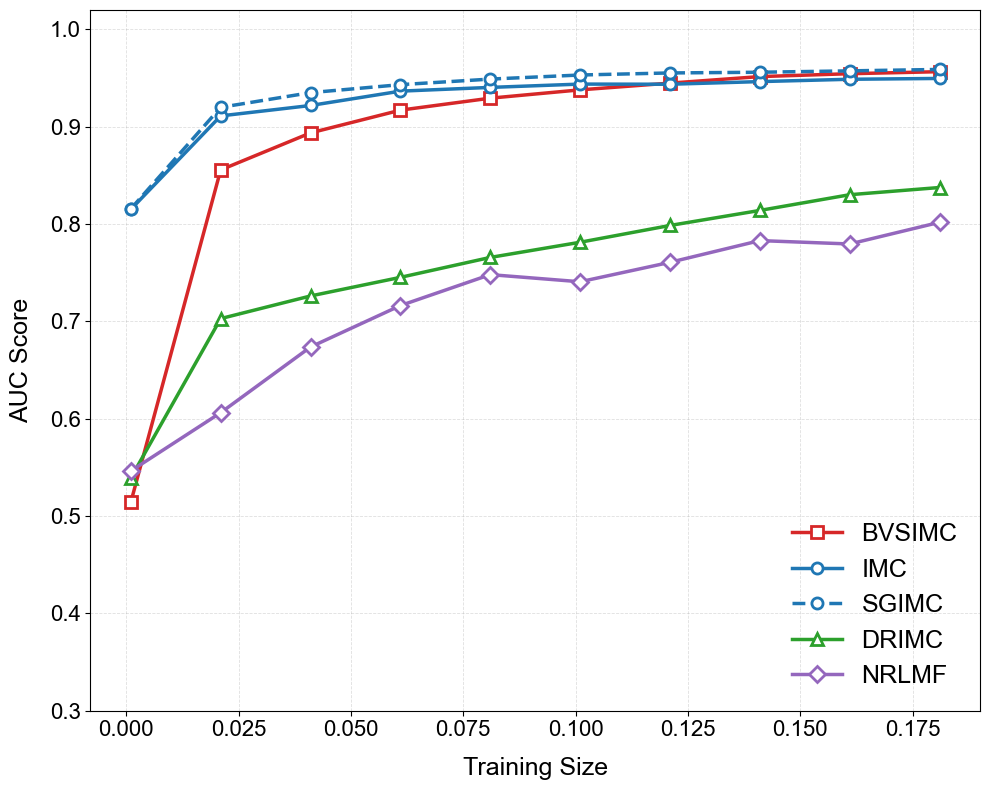

In [48]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(10, 8))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BVSIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "tb_roc_auc_comparison_separate.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

## Case 2: noisy

In [49]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/tuberculosis/noisy")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [50]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/noisy/results_bissgl.gz']

In [51]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [52]:
results

[[{'combo_idx': 0,
   'train_size': 0.001,
   'xi': 1,
   'eta': 2e-07,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 13,
   'test_score': 0.5877866967064627,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 1,
   'train_size': 0.001,
   'xi': 2,
   'eta': 2e-07,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 13,
   'test_score': 0.5103991190557714,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 2,
   'train_size': 0.001,
   'xi': 3,
   'eta': 2e-07,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 13,
   'test_score': 0.448698772665438,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 3,
   'train_size': 0.001,
   'xi': 4,
   'eta': 2e-07,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 13,
   'test_score': 0.4886745648394643,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 10,
   'train_size': 0.02

In [53]:
results_final = []
for result in results:
    results_final.append(get_test_results(result, param="train_size", hyp_param="xi"))
results_final = np.array(results_final)
results_bissgl = np.mean(results_final, axis=0)

In [54]:
results_final = []
for result in results:
    results_final.append(get_test_results(result, param="xi", hyp_param="xi"))
results_final = np.array(results_final)
results_bissgl_xi = np.mean(results_final, axis=0)

In [55]:
results_bissgl = np.sort(results_bissgl)

In [56]:
results_bissgl

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.60247674, 0.84062999, 0.84254361, 0.86016977, 0.87384878,
        0.87968501, 0.8854405 , 0.90005948, 0.90040889, 0.90090095]])

### IMC

In [57]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/noisy/results_imc.gz']

In [58]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [59]:
results

[[{'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 13,
   'cv': 0,
   'val_score': 0.5,
   'test_score': 0.49918831734335084},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 13,
   'cv': 1,
   'val_score': 0.5,
   'test_score': 0.49918831734335084},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 13,
   'cv': 2,
   'val_score': 0.47222222222222227,
   'test_score': 0.49918831734335084},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 13,
   'cv': 3,
   'val_score': 0.5,
   'test_score': 0.49918831734335084},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 13,
   'cv': 4,
   'val_score': 0.5,
   'test_score': 0.49918831734335084},
  {'train_size': 0.001,
   'lamb': 0.001,
   'rank': 13,
   'cv': 0,
   'val_score': 0.6625000000000001,
   'test_score': 0.6562937778906235},
  {'train_size': 0.001,
   'lamb': 0.001,
   'rank': 13,
   'cv': 1,
   'val_score': 0.5,
   'test_score': 0.6562937778906235},
  {'train_size': 0.001,
   'lamb': 0.001,
   'rank': 13,
   'cv

In [60]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="lamb")
    )
results_final = np.array(results_final)
results_imc = np.mean(results_final, axis=0)

In [61]:
results_imc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.65629378, 0.73634963, 0.71151863, 0.75395327, 0.75355421,
        0.76874098, 0.77324119, 0.77137524, 0.77318724, 0.77552836]])

### SGIMC

In [62]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/noisy/results_sgimc.gz']

In [63]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [64]:
results

[[{'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 0,
   'rank': 13,
   'val_score': 0.7638888888888888,
   'val_d1': 6635,
   'val_d2': 22,
   'test_score': 0.6736508218214871,
   'test_d1': 6860,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 1,
   'rank': 13,
   'val_score': 0.7532467532467533,
   'val_d1': 6591,
   'val_d2': 22,
   'test_score': 0.6736508218214871,
   'test_d1': 6860,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 2,
   'rank': 13,
   'val_score': 0.5972222222222222,
   'val_d1': 6848,
   'val_d2': 22,
   'test_score': 0.6736508218214871,
   'test_d1': 6860,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 3,
   'rank': 13,
   'val_score': 0.5974025974025974,
   'val_d1': 6813,
   'val_d2': 22,
   'test_score': 0.6736508218214871,
   'test_d1': 6860,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 4,
   'rank': 13,
   'val_score': 0.5,
   'val_d1': 6993,
   

In [65]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="C_group")
    )
results_final = np.array(results_final)
results_sgimc = np.mean(results_final, axis=0)

In [66]:
results_sgimc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.67635326, 0.74822591, 0.74316842, 0.79002995, 0.8034865 ,
        0.8062613 , 0.81577996, 0.81621637, 0.82538736, 0.82699213]])

### DRIMC

In [67]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "20260112_222923results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/noisy/20260112_222923results_drimc.gz']

In [68]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [69]:
results

[[{'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 1,
   'iterpara': 0.09,
   'numLat': 200,
   'test_score': 0.6155782933794616,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 2,
   'iterpara': 0.09,
   'numLat': 200,
   'test_score': 0.6162397924816343,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 3,
   'iterpara': 0.09,
   'numLat': 200,
   'test_score': 0.6168300499953562,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 4,
   'iterpara': 0.09,
   'numLat': 200,
   'test_score': 0.6173183691773687,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 5,
   'iterpara': 0.09,
   'numLat': 200,
   'test_score': 0.6176541475464633,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.09,
   'lamV': 0.09,
   'cc': 6,
   'i

In [70]:
results_final = []
for result in results:
    results_final.append(get_test_results(result, param="train_size", hyp_param="cc"))
results_final = np.array(results_final)
results_drimc = np.mean(results_final, axis=0)

In [71]:
results_drimc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.61901319, 0.73190381, 0.7307079 , 0.73281329, 0.74831829,
        0.77042068, 0.78892427, 0.8012355 , 0.8106419 , 0.81712352]])

### NRLMF

In [72]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/noisy/results_nrlmf.gz']

In [73]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [74]:
results

[[{'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': 0.3765061808922311,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': 0.5400407982790087,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 5,
   'r': 50,
   'test_score': 0.7124923954014915,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 7,
   'r': 50,
   'test_score': 0.4512319972236682,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 9,
   'r': 50,
   'test_score': 0.39536537613232736,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.021,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': 0.5244659533501,
   'test_d1': 6949,
   'test_d2': 13},


In [ ]:
results_final = []
for result in results:
    results_final.append(
        get_test_results(result, param="train_size", hyp_param="train_size")
    )
results_final = np.array(results_final)
results_nrlmf = np.mean(results_final, axis=0)

In [76]:
results_nrlmf

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.451232  , 0.55589202, 0.59986594, 0.6614023 , 0.66470468,
        0.70548231, 0.72859836, 0.76164361, 0.75389052, 0.7758883 ]])

---

### Plot figures

In [169]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/tuberculosis")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

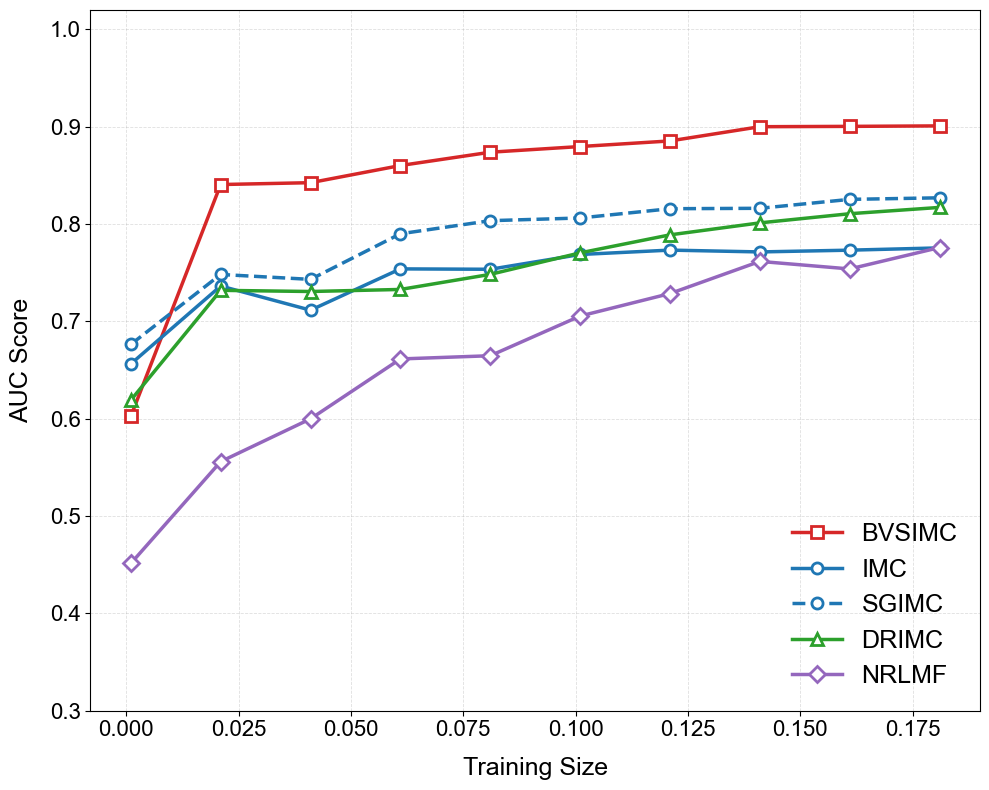

In [77]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(10, 8))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BVSIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "tb_roc_auc_comparison_noisy.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

#### Extra plots

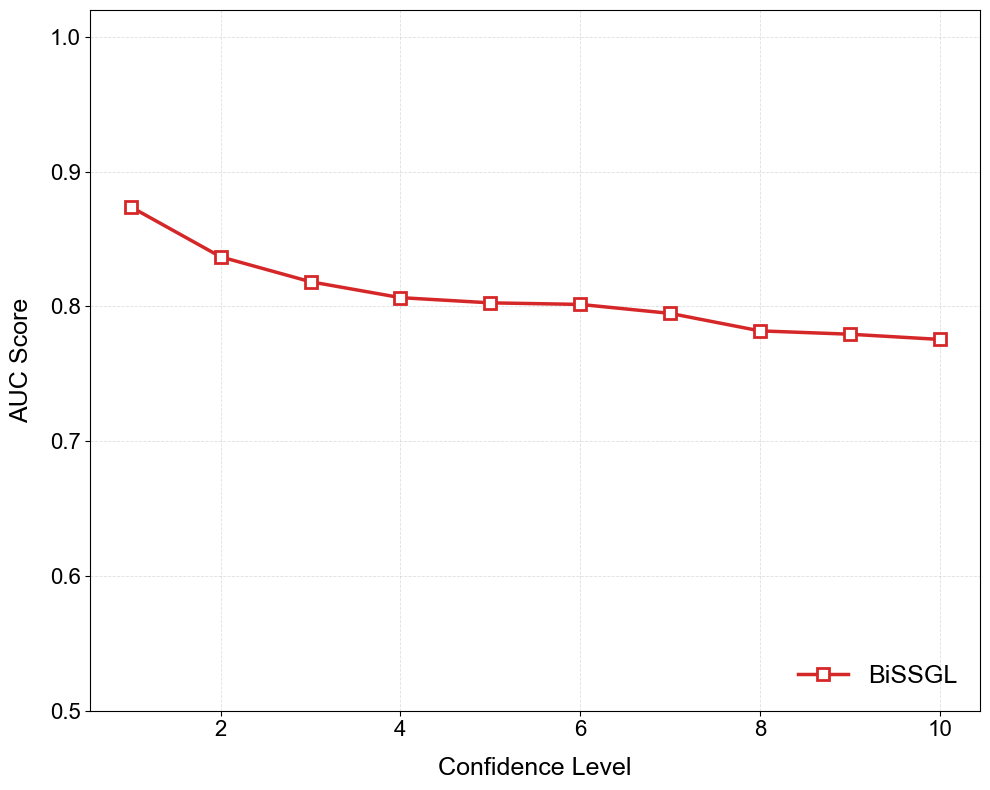

In [171]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(10, 8))

# Curves + markers (single call each)
plt.plot(
    results_bissgl_xi[0],
    results_bissgl_xi[1],
    label="BiSSGL",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

# Axis limits and labels
plt.ylim(0.5, 1.02)
plt.xlabel("Confidence Level", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_confidence_noisy.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()